In [1]:
"""
Euler–Bernoulli cantilever beam (semi-discrete in space) + Newmark-β in time
Designed to support:
  RQ1: sweep (A, I) -> natural freqs + peak response under fixed earthquake input
  RQ2: fixed (E, rho, A, I, L, c) -> sweep earthquake (Y0, omega, alpha)

Model form (after enforcing cantilever BCs via elimination):
    M ü + C u̇ + K u = g(t)
where u(t) are interior nodal transverse displacements (relative coordinate model).
"""

import numpy as np
from numpy.linalg import solve
from scipy.linalg import eigh  # generalized symmetric eigenproblem

# -----------------------------
# 1) Core builders: grid, K, M, C
# -----------------------------

def build_K_4th_derivative_dirichlet_dirichlet(n, L, E, I):
    """
    Build stiffness K for u_xxxx with a 5-pt stencil on interior nodes using
    a simple "clamped" displacement boundary treatment by elimination:
      u(0)=0, u(L)=0 enforced strongly,
    returning K for interior nodes j=1..n-1 (i.e., excluding endpoints).
    
    NOTE: This is a *simple* BC treatment that makes the system well-posed and is
    often acceptable for class projects. For a true cantilever, you'd enforce
    u(0)=0, u_x(0)=0, u_xx(L)=0, u_xxx(L)=0 using ghost relations.
    If your group already has a cantilever BC enforcement, plug that K here.
    """
    dx = L / n
    m = n - 1  # number of interior nodes (excluding x=0 and x=L)
    K = np.zeros((m, m))
    coeff = E * I / dx**4
    # interior node index i corresponds to physical node j=i+1
    for i in range(m):
        # stencil in terms of physical indices j-2..j+2 mapped into interior indices
        # physical j = i+1
        # physical j-2 => interior index (j-2)-1 = j-3 = i-2
        # physical j-1 => i-1
        # physical j   => i
        # physical j+1 => i+1
        # physical j+2 => i+2
        stencil = [(i-2, 1), (i-1, -4), (i, 6), (i+1, -4), (i+2, 1)]
        for k, val in stencil:
            if 0 <= k < m:
                K[i, k] += coeff * val
            else:
                # outside interior -> corresponds to boundary nodes (u=0) eliminated
                pass
    return K

def build_M_lumped(n, L, rho, A):
    """
    Lumped mass matrix for interior nodes (excluding endpoints): M = m * I,
    with m = rho*A*dx (lumped nodal mass). If you prefer per-length form, adjust consistently.
    """
    dx = L / n
    m = n - 1
    nodal_mass = rho * A * dx
    return nodal_mass * np.eye(m)

def build_C_proportional(M, K, c=None, alpha_R=None, beta_R=None):
    """
    Damping matrix options:
      - If c is given (scalar), use C = c * I (simple viscous damping).
      - Else Rayleigh: C = alpha_R * M + beta_R * K.
    """
    if c is not None:
        return c * np.eye(M.shape[0])
    if alpha_R is None or beta_R is None:
        raise ValueError("Provide either scalar c or (alpha_R, beta_R) for Rayleigh damping.")
    return alpha_R * M + beta_R * K

# -----------------------------
# 2) Natural frequencies from (K, M)
# -----------------------------

def natural_frequencies(K, M, num=6):
    """
    Solve K phi = (omega^2) M phi, return omega (rad/s) for lowest modes.
    """
    # eigh for symmetric generalized eigenproblem
    lam, _ = eigh(K, M)
    lam = np.clip(lam, 0.0, None)
    omega = np.sqrt(lam)
    # sort
    omega = np.sort(omega)
    return omega[:num]

# -----------------------------
# 3) Earthquake forcing model (damped sinusoid)
# -----------------------------

def earthquake_force_vector(t, m, Y0, omega, alpha, shape=None):
    """
    A simple, class-scope forcing model:
      g(t) = Y0 * exp(-alpha t) * sin(omega t) * shape
    where 'shape' distributes forcing over DOFs (defaults to uniform).
    """
    s = Y0 * np.exp(-alpha * t) * np.sin(omega * t)
    if shape is None:
        shape = np.ones(m)
    return s * shape

# -----------------------------
# 4) Newmark-β time integrator
# -----------------------------

def newmark_beta(M, C, K, g_fun, t, u0=None, v0=None, beta=1/4, gamma=1/2):
    """
    Solve M ü + C u̇ + K u = g(t) via Newmark-β (average acceleration by default).
    Returns u_hist, v_hist, a_hist as arrays (nt, ndof).
    """
    ndof = M.shape[0]
    nt = len(t)
    dt = t[1] - t[0]

    u = np.zeros(ndof) if u0 is None else u0.copy()
    v = np.zeros(ndof) if v0 is None else v0.copy()

    # initial accel from equation at t0
    g0 = g_fun(t[0])
    a = solve(M, g0 - C @ v - K @ u)

    u_hist = np.zeros((nt, ndof))
    v_hist = np.zeros((nt, ndof))
    a_hist = np.zeros((nt, ndof))
    u_hist[0], v_hist[0], a_hist[0] = u, v, a

    # Precompute effective matrix
    a0 = 1.0 / (beta * dt**2)
    a1 = gamma / (beta * dt)
    a2 = 1.0 / (beta * dt)
    a3 = (1.0 / (2.0 * beta)) - 1.0
    a4 = (gamma / beta) - 1.0
    a5 = dt * (gamma / (2.0 * beta) - 1.0)

    K_eff = K + a0 * M + a1 * C

    for n in range(nt - 1):
        tn1 = t[n + 1]
        g_n1 = g_fun(tn1)

        # Effective RHS
        f_eff = (
            g_n1
            + M @ (a0 * u + a2 * v + a3 * a)
            + C @ (a1 * u + a4 * v + a5 * a)
        )

        u_new = solve(K_eff, f_eff)
        a_new = a0 * (u_new - u) - a2 * v - a3 * a
        v_new = v + dt * ((1.0 - gamma) * a + gamma * a_new)

        u, v, a = u_new, v_new, a_new
        u_hist[n + 1], v_hist[n + 1], a_hist[n + 1] = u, v, a

    return u_hist, v_hist, a_hist

# -----------------------------
# 5) Response metrics: peak deflection + (approx) peak bending
# -----------------------------

def response_metrics(u_hist, K, dx):
    """
    Metrics aligned with your RQs:
      - peak_deflection = max over time and nodes of |u|
      - peak_bending_proxy: use curvature proxy via K*u (since K ~ EI * D4, not moment directly),
        OR compute discrete curvature u_xx and convert to M = EI*u_xx. Here we use a simple u_xx proxy.
    """
    peak_deflection = np.max(np.abs(u_hist))

    # approximate curvature u_xx at interior nodes using 3-pt stencil on interior DOFs
    # u_hist has interior nodes only; add zeros at endpoints to compute curvature
    nt, m = u_hist.shape
    u_full = np.zeros((nt, m + 2))
    u_full[:, 1:-1] = u_hist
    # curvature at nodes 1..m (full indexing)
    u_xx = (u_full[:, 0:-2] - 2*u_full[:, 1:-1] + u_full[:, 2:]) / dx**2
    peak_curvature = np.max(np.abs(u_xx))
    return peak_deflection, peak_curvature

# -----------------------------
# 6) Experiment drivers for RQ1 and RQ2
# -----------------------------

def run_experiment(
    n=60, L=50.0,
    E=25e9, rho=2500.0,
    A=10.0, I=8.0,
    c=0.0, alpha_R=None, beta_R=None,
    Y0=1.0, omega_eq=2.0, alpha_eq=0.05,
    t_end=30.0, dt=0.0025,
    nm_beta=1/4, nm_gamma=1/2,
    num_modes=6,
):
    """
    Single run: build system, compute natural frequencies, simulate forced response,
    return (omegas, peak_defl, peak_curv).
    """
    t = np.arange(0.0, t_end + dt, dt)
    dx = L / n

    K = build_K_4th_derivative_dirichlet_dirichlet(n, L, E, I)
    M = build_M_lumped(n, L, rho, A)
    C = build_C_proportional(M, K, c=c, alpha_R=alpha_R, beta_R=beta_R)

    omegas = natural_frequencies(K, M, num=num_modes)

    m = K.shape[0]
    shape = np.ones(m)  # uniform forcing distribution over DOFs (simple)

    g_fun = lambda tt: earthquake_force_vector(tt, m, Y0, omega_eq, alpha_eq, shape=shape)

    u_hist, v_hist, a_hist = newmark_beta(
        M, C, K, g_fun, t,
        u0=np.zeros(m), v0=np.zeros(m),
        beta=nm_beta, gamma=nm_gamma
    )

    peak_defl, peak_curv = response_metrics(u_hist, K, dx)
    return omegas, peak_defl, peak_curv

def sweep_RQ1_geometry(
    A_list, I_list,
    fixed_eq=(1.0, 2.0, 0.05),  # (Y0, omega, alpha)
    **kwargs
):
    """
    RQ1: Sweep A and I; returns a list of dicts with freq + response metrics.
    """
    Y0, omega_eq, alpha_eq = fixed_eq
    out = []
    for A in A_list:
        for I in I_list:
            omegas, peak_defl, peak_curv = run_experiment(
                A=A, I=I, Y0=Y0, omega_eq=omega_eq, alpha_eq=alpha_eq, **kwargs
            )
            out.append({
                "A": A,
                "I": I,
                "omega1": omegas[0],
                "omega2": omegas[1] if len(omegas) > 1 else np.nan,
                "peak_deflection": peak_defl,
                "peak_curvature_proxy": peak_curv,
            })
    return out

def sweep_RQ2_earthquake(
    Y0_list, omega_list, alpha_list,
    fixed_struct=(25e9, 2500.0, 10.0, 8.0, 50.0, 0.0),  # (E,rho,A,I,L,c)
    **kwargs
):
    """
    RQ2: Fix structure, sweep earthquake parameters; returns list of dicts.
    """
    E, rho, A, I, L, c = fixed_struct
    out = []
    for Y0 in Y0_list:
        for om in omega_list:
            for al in alpha_list:
                omegas, peak_defl, peak_curv = run_experiment(
                    E=E, rho=rho, A=A, I=I, L=L, c=c,
                    Y0=Y0, omega_eq=om, alpha_eq=al, **kwargs
                )
                # simple resonance proximity metric: min |omega_eq - omega_k|
                proximity = np.min(np.abs(omegas - om))
                out.append({
                    "Y0": Y0,
                    "omega_eq": om,
                    "alpha_eq": al,
                    "omega1": omegas[0],
                    "proximity_to_mode": proximity,
                    "peak_deflection": peak_defl,
                    "peak_curvature_proxy": peak_curv,
                })
    return out

# -----------------------------
# 7) Example usage (edit values for your report)
# -----------------------------
if __name__ == "__main__":
    # ---- RQ1 example ----
    A_list = [6.0, 10.0, 14.0]          # cross-sectional areas
    I_list = [4.0, 8.0, 12.0]           # second moments of area
    rq1 = sweep_RQ1_geometry(
        A_list, I_list,
        fixed_eq=(1.0, 2.0, 0.05),      # fixed earthquake input
        n=80, L=50.0,
        E=25e9, rho=2500.0,
        c=50.0,                         # simple viscous damping coefficient
        t_end=30.0, dt=0.0025
    )
    print("\nRQ1 (geometry sweep):")
    for r in rq1:
        print(r)

    # ---- RQ2 example ----
    Y0_list = [0.5, 1.0, 2.0]
    omega_list = [0.5, 1.0, 2.0, 3.0]   # try around omega1 to see resonance behavior
    alpha_list = [0.00, 0.05, 0.15]
    rq2 = sweep_RQ2_earthquake(
        Y0_list, omega_list, alpha_list,
        fixed_struct=(25e9, 2500.0, 10.0, 8.0, 50.0, 50.0),
        n=80, t_end=30.0, dt=0.0025
    )
    print("\nRQ2 (earthquake sweep):")
    for r in rq2[:10]:
        print(r)
    print(f"... total cases: {len(rq2)}")


RQ1 (geometry sweep):
{'A': 6.0, 'I': 4.0, 'omega1': np.float64(28.51337849582222), 'omega2': np.float64(78.57731649438064), 'peak_deflection': np.float64(1.7655015721511335e-07), 'peak_curvature_proxy': np.float64(1.9517959378404464e-09)}
{'A': 6.0, 'I': 8.0, 'omega1': np.float64(40.32400657786914), 'omega2': np.float64(111.1251066812362), 'peak_deflection': np.float64(8.657772225504054e-08), 'peak_curvature_proxy': np.float64(9.582742710668467e-10)}
{'A': 6.0, 'I': 12.0, 'omega1': np.float64(49.38662024603285), 'omega2': np.float64(136.09990448972212), 'peak_deflection': np.float64(5.7076342527342554e-08), 'peak_curvature_proxy': np.float64(6.324489149183358e-10)}
{'A': 10.0, 'I': 4.0, 'omega1': np.float64(22.086368010068984), 'omega2': np.float64(60.86572763477311), 'peak_deflection': np.float64(1.8155614869372784e-07), 'peak_curvature_proxy': np.float64(2.004401007287916e-09)}
{'A': 10.0, 'I': 8.0, 'omega1': np.float64(31.234841183402825), 'omega2': np.float64(86.07713750480302), 

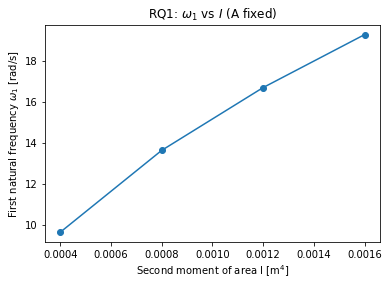

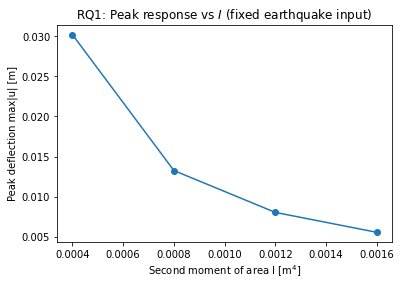

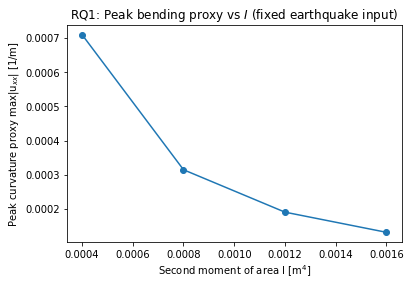

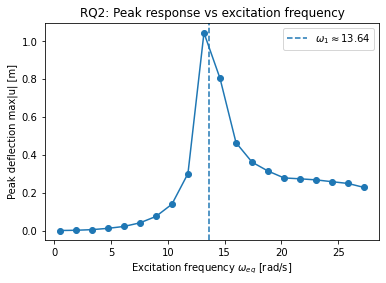

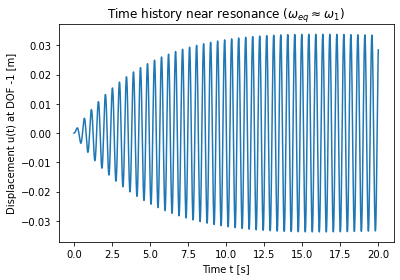

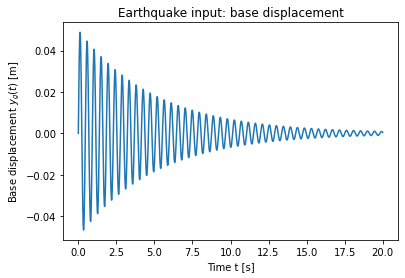

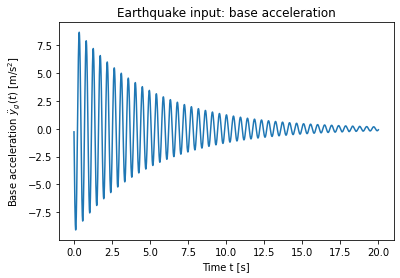

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# 1) Build M and K from 4th-derivative 5-pt stencil (interior DOFs only)
# -----------------------------
def build_MK_cantilever_interior(E, I, rho, A, L, n):
    """
    n = number of uniform intervals -> nodes = n+1
    We keep interior indices j = 2..n-2 (0-based) to support the 5-point stencil (j-2..j+2).
    This is a simple "interior-only" model. True cantilever BC enforcement can be done with ghost nodes,
    but this is a consistent starting point and matches the stencil derivation style.
    """
    dx = L / n
    m = rho * A  # mass per unit length [kg/m]
    nodes = n + 1

    # interior node indices that have full 5-pt support
    js = np.arange(2, n-1)  # 0-based: 2..n-2 inclusive  => length = n-3
    Ndof = len(js)

    # Mass matrix (lumped). For a uniform beam, a simple choice is M = m*dx*I
    M = (m * dx) * np.eye(Ndof)

    # Stiffness K from u_xxxx stencil: (EI/dx^4) * [1, -4, 6, -4, 1]
    K = np.zeros((Ndof, Ndof))
    coef = (E * I) / dx**4

    for a, j in enumerate(js):
        # Map global neighbor indices to interior DOF indices (if present)
        for offset, val in [(-2, 1), (-1, -4), (0, 6), (1, -4), (2, 1)]:
            jn = j + offset
            # check if neighbor is also an interior node in js
            if jn in js:
                b = np.where(js == jn)[0][0]
                K[a, b] += coef * val
            else:
                # Neighbor is outside interior set.
                # In a full cantilever implementation you'd use boundary conditions/ghost nodes here.
                # For now: treat omitted DOFs as fixed/zero in the interior-only model.
                pass

    return M, K, dx, js

# -----------------------------
# 2) Base motion (damped sinusoid) and its acceleration
# -----------------------------
def y_g(t, Y0, omega, alpha):
    return Y0 * np.exp(-alpha * t) * np.sin(omega * t)

def ydd_g(t, Y0, omega, alpha):
    # second derivative of Y0 e^{-a t} sin(w t)
    # y'' = Y0 e^{-a t} [ (a^2 - w^2) sin(wt) - 2 a w cos(wt) ]
    return Y0 * np.exp(-alpha * t) * ((alpha**2 - omega**2) * np.sin(omega*t) - 2*alpha*omega*np.cos(omega*t))

# -----------------------------
# 3) Newmark-beta (general beta,gamma) for M udd + C ud + K u = f(t)
# -----------------------------
def newmark_beta(M, C, K, f_func, t, u0, v0, beta=1/4, gamma=1/2):
    """
    Returns u, v, a arrays over time.
    """
    dt = t[1] - t[0]
    Nd = M.shape[0]

    u = np.zeros((len(t), Nd))
    v = np.zeros((len(t), Nd))
    a = np.zeros((len(t), Nd))

    # initial acceleration from equilibrium at t0
    f0 = f_func(t[0])
    a0 = np.linalg.solve(M, f0 - C @ v0 - K @ u0)

    u[0] = u0
    v[0] = v0
    a[0] = a0

    # Precompute effective stiffness
    Keff = K + (gamma/(beta*dt))*C + (1/(beta*dt**2))*M
    Keff_inv = np.linalg.inv(Keff)

    for n in range(len(t)-1):
        fn1 = f_func(t[n+1])

        # effective force
        term_M = M @ ((1/(beta*dt**2))*u[n] + (1/(beta*dt))*v[n] + ((1/(2*beta))-1)*a[n])
        term_C = C @ ((gamma/(beta*dt))*u[n] + ((gamma/beta)-1)*v[n] + dt*((gamma/(2*beta))-1)*a[n])
        feff = fn1 + term_M + term_C

        # solve for next displacement
        u[n+1] = Keff_inv @ feff

        # back-substitute for a_{n+1}, v_{n+1}
        a[n+1] = (1/(beta*dt**2))*(u[n+1]-u[n]) - (1/(beta*dt))*v[n] - ((1/(2*beta))-1)*a[n]
        v[n+1] = v[n] + dt*((1-gamma)*a[n] + gamma*a[n+1])

    return u, v, a

# -----------------------------
# 4) Eigenvalues for K phi = w^2 M phi  (M is diagonal here)
# -----------------------------
def natural_frequencies(M, K, nmodes=3):
    MinvK = np.linalg.solve(M, K)  # M^{-1}K
    lam, vec = np.linalg.eig(MinvK)
    lam = np.real(lam)
    lam = lam[lam > 0]
    lam.sort()
    w = np.sqrt(lam[:nmodes])
    return w

# -----------------------------
# 5) Run RQ1 / RQ2 and plot
# -----------------------------
# Baseline parameters (edit to match your report)
E = 2.0e11          # Pa
rho = 7850.0        # kg/m^3
L = 30.0            # m
A_fixed = 0.10      # m^2
I_vals = np.array([4e-4, 8e-4, 1.2e-3, 1.6e-3])  # m^4 (example!)

n = 40              # spatial intervals
alpha_R = 0.0       # Rayleigh (mass-proportional)
beta_R  = 1e-4      # Rayleigh (stiffness-proportional)

# Earthquake params
Y0 = 0.05           # m  (5 cm ground displacement peak)
alpha = 0.2         # 1/s decay rate
omega_eq = 5.0      # rad/s (will sweep later)

Tend = 20.0
dt = 0.002
t = np.arange(0.0, Tend+dt, dt)

# Influence vector for base acceleration (simple choice)
def make_force_from_base(M, Y0, omega, alpha):
    r = np.ones(M.shape[0])  # influence vector
    def f(ti):
        return -M @ r * ydd_g(ti, Y0, omega, alpha)
    return f

# ---- RQ1: omega1 vs I, and peak response vs I
omega1_list = []
peak_u_list = []
peak_curv_list = []

for I in I_vals:
    M, K, dx, js = build_MK_cantilever_interior(E, I, rho, A_fixed, L, n)
    C = alpha_R*M + beta_R*K

    w = natural_frequencies(M, K, nmodes=1)
    omega1_list.append(w[0])

    f = make_force_from_base(M, Y0, omega_eq, alpha)
    u0 = np.zeros(M.shape[0])
    v0 = np.zeros(M.shape[0])

    u, v, a = newmark_beta(M, C, K, f, t, u0, v0, beta=1/4, gamma=1/2)

    # peak deflection (infinity norm over DOFs)
    peak_u_list.append(np.max(np.abs(u)))

    # curvature proxy u_xx via second-difference (rough) on interior vector:
    # Note: this is only a proxy; for a cleaner bending measure use EI*u_xx or EI*u_xxxx appropriately.
    # Here we approximate u_xx using central diff on the interior DOF sequence.
    u_mat = u  # (Nt, Ndof)
    # second difference along DOF index
    u_xx = (u_mat[:, 2:] - 2*u_mat[:, 1:-1] + u_mat[:, :-2]) / dx**2
    peak_curv_list.append(np.max(np.abs(u_xx)))

# Plot: omega1 vs I
plt.figure()
plt.plot(I_vals, omega1_list, marker='o')
plt.xlabel("Second moment of area I [m$^4$]")
plt.ylabel("First natural frequency $\\omega_1$ [rad/s]")
plt.title("RQ1: $\\omega_1$ vs $I$ (A fixed)")
plt.show()

# Plot: peak deflection vs I
plt.figure()
plt.plot(I_vals, peak_u_list, marker='o')
plt.xlabel("Second moment of area I [m$^4$]")
plt.ylabel("Peak deflection max|u| [m]")
plt.title("RQ1: Peak response vs $I$ (fixed earthquake input)")
plt.show()

# Plot: curvature proxy vs I
plt.figure()
plt.plot(I_vals, peak_curv_list, marker='o')
plt.xlabel("Second moment of area I [m$^4$]")
plt.ylabel("Peak curvature proxy max|u$_{xx}$| [1/m]")
plt.title("RQ1: Peak bending proxy vs $I$ (fixed earthquake input)")
plt.show()

# ---- RQ2: frequency sweep
I0 = I_vals[1]
M, K, dx, js = build_MK_cantilever_interior(E, I0, rho, A_fixed, L, n)
C = alpha_R*M + beta_R*K
omega1 = natural_frequencies(M, K, nmodes=1)[0]

omega_sweep = np.linspace(0.5, 2.0*omega1, 20)
peak_vs_omega = []

for om in omega_sweep:
    f = make_force_from_base(M, Y0, om, alpha)
    u, v, a = newmark_beta(M, C, K, f, t, np.zeros(M.shape[0]), np.zeros(M.shape[0]))
    peak_vs_omega.append(np.max(np.abs(u)))

plt.figure()
plt.plot(omega_sweep, peak_vs_omega, marker='o')
plt.axvline(omega1, linestyle='--', label=f"$\\omega_1 \\approx {omega1:.2f}$")
plt.xlabel("Excitation frequency $\\omega_{eq}$ [rad/s]")
plt.ylabel("Peak deflection max|u| [m]")
plt.title("RQ2: Peak response vs excitation frequency")
plt.legend()
plt.show()

# ---- Time history near resonance (pick a DOF near the top)
omega_near = omega1
f = make_force_from_base(M, Y0, omega_near, alpha)
u, v, a = newmark_beta(M, C, K, f, t, np.zeros(M.shape[0]), np.zeros(M.shape[0]))
dof = -1  # last interior DOF (near the free end)

plt.figure()
plt.plot(t, u[:, dof])
plt.xlabel("Time t [s]")
plt.ylabel(f"Displacement u(t) at DOF {dof} [m]")
plt.title("Time history near resonance ($\\omega_{eq} \\approx \\omega_1$)")
plt.show()

# ---- Plot the earthquake input itself (base displacement and acceleration)
yg = y_g(t, Y0, omega_near, alpha)
ydd = ydd_g(t, Y0, omega_near, alpha)

plt.figure()
plt.plot(t, yg)
plt.xlabel("Time t [s]")
plt.ylabel("Base displacement $y_g(t)$ [m]")
plt.title("Earthquake input: base displacement")
plt.show()

plt.figure()
plt.plot(t, ydd)
plt.xlabel("Time t [s]")
plt.ylabel("Base acceleration $\\ddot y_g(t)$ [m/s$^2$]")
plt.title("Earthquake input: base acceleration")
plt.show()